# Advanced Visualization & Analysis - Construction PPE Dataset
Comprehensive analysis dengan visualisasi advanced untuk understanding dataset dengan mendalam

## 1. Setup & Load Data

In [15]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Setup
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

dataset_root = '../data'
processed_root = '../data/processed'
splits = ['train', 'val', 'test']

class_names = {
    0: 'helmet', 1: 'gloves', 2: 'vest', 3: 'boots', 4: 'goggles',
    5: 'none', 6: 'Person', 7: 'no_helmet', 8: 'no_goggle',
    9: 'no_gloves', 10: 'no_boots'
}

ppe_classes = {0: 'helmet', 1: 'gloves', 2: 'vest', 3: 'boots', 4: 'goggles'}
print('✓ Libraries loaded & configurations set')

✓ Libraries loaded & configurations set


## 2. Advanced Image Analysis

In [16]:
# Comprehensive image dimension & property analysis
image_properties = defaultdict(lambda: {
    'sizes': [], 'widths': [], 'heights': [], 'aspect_ratios': [],
    'formats': Counter(), 'file_sizes': []
})

for split in splits:
    images_path = os.path.join(dataset_root, 'images', split)
    if os.path.exists(images_path):
        for img_file in os.listdir(images_path):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(images_path, img_file)
                img = cv2.imread(img_path)
                
                if img is not None:
                    h, w = img.shape[:2]
                    file_size = os.path.getsize(img_path) / (1024)  # KB
                    aspect_ratio = w / h
                    image_size = (h * w) / (1000000)  # Megapixels
                    
                    image_properties[split]['widths'].append(w)
                    image_properties[split]['heights'].append(h)
                    image_properties[split]['aspect_ratios'].append(aspect_ratio)
                    image_properties[split]['file_sizes'].append(file_size)
                    image_properties[split]['sizes'].append(image_size)
                    image_properties[split]['formats'][img_file.split('.')[-1].upper()] += 1

# Display statistics
print('IMAGE DIMENSION ANALYSIS')
print('='*80)
for split in splits:
    props = image_properties[split]
    print(f'\n{split.upper()}: {len(props["widths"])} images')
    print(f'  Width:  {np.mean(props["widths"]):.0f}px (±{np.std(props["widths"]):.0f}), Range: {np.min(props["widths"])} - {np.max(props["widths"])}')
    print(f'  Height: {np.mean(props["heights"]):.0f}px (±{np.std(props["heights"]):.0f}), Range: {np.min(props["heights"])} - {np.max(props["heights"])}')
    print(f'  Aspect Ratio: {np.mean(props["aspect_ratios"]):.2f}x (±{np.std(props["aspect_ratios"]):.2f})')
    print(f'  Megapixels: {np.mean(props["sizes"]):.2f}MP (±{np.std(props["sizes"]):.2f})')
    print(f'  File Size: {np.mean(props["file_sizes"]):.1f}KB (±{np.std(props["file_sizes"]):.1f})')
    print(f'  Formats: {dict(props["formats"])}')

IMAGE DIMENSION ANALYSIS

TRAIN: 1132 images
  Width:  690px (±126), Range: 408 - 1024
  Height: 672px (±113), Range: 263 - 1024
  Aspect Ratio: 1.04x (±0.18)
  Megapixels: 0.47MP (±0.15)
  File Size: 125.3KB (±134.7)
  Formats: {'JPG': 1013, 'JPEG': 119}

VAL: 143 images
  Width:  686px (±120), Range: 612 - 1024
  Height: 668px (±112), Range: 401 - 1024
  Aspect Ratio: 1.04x (±0.18)
  Megapixels: 0.46MP (±0.14)
  File Size: 111.4KB (±113.0)
  Formats: {'JPG': 123, 'JPEG': 20}

TEST: 141 images
  Width:  686px (±116), Range: 612 - 1024
  Height: 686px (±122), Range: 425 - 1024
  Aspect Ratio: 1.01x (±0.15)
  Megapixels: 0.48MP (±0.15)
  File Size: 119.6KB (±129.2)
  Formats: {'JPEG': 14, 'JPG': 127}


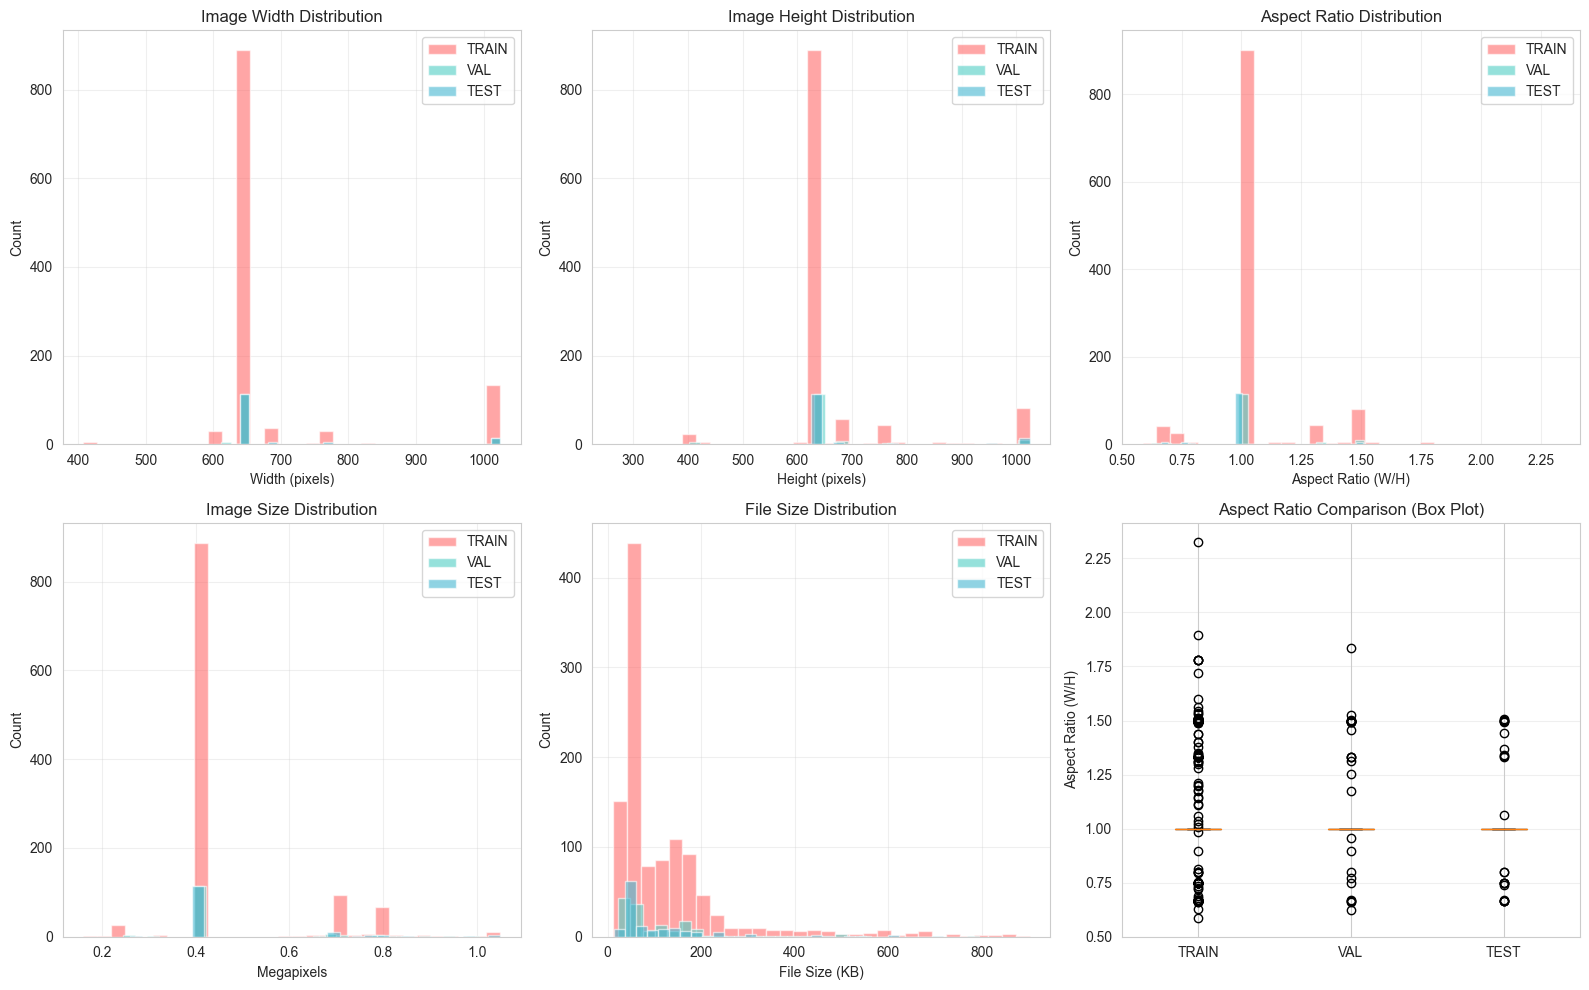

✓ Image analysis visualization saved


In [17]:
# Visualize dimension distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# Width distribution
for idx, split in enumerate(splits):
    axes[0, 0].hist(image_properties[split]['widths'], alpha=0.6, label=split.upper(), color=colors[idx], bins=30)
axes[0, 0].set_xlabel('Width (pixels)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Image Width Distribution')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Height distribution
for idx, split in enumerate(splits):
    axes[0, 1].hist(image_properties[split]['heights'], alpha=0.6, label=split.upper(), color=colors[idx], bins=30)
axes[0, 1].set_xlabel('Height (pixels)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Image Height Distribution')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Aspect ratio distribution
for idx, split in enumerate(splits):
    axes[0, 2].hist(image_properties[split]['aspect_ratios'], alpha=0.6, label=split.upper(), color=colors[idx], bins=30)
axes[0, 2].set_xlabel('Aspect Ratio (W/H)')
axes[0, 2].set_ylabel('Count')
axes[0, 2].set_title('Aspect Ratio Distribution')
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

# Megapixels distribution
for idx, split in enumerate(splits):
    axes[1, 0].hist(image_properties[split]['sizes'], alpha=0.6, label=split.upper(), color=colors[idx], bins=30)
axes[1, 0].set_xlabel('Megapixels')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Image Size Distribution')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# File size distribution
for idx, split in enumerate(splits):
    axes[1, 1].hist(image_properties[split]['file_sizes'], alpha=0.6, label=split.upper(), color=colors[idx], bins=30)
axes[1, 1].set_xlabel('File Size (KB)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('File Size Distribution')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# Box plot comparison
box_data = [image_properties[s]['aspect_ratios'] for s in splits]
axes[1, 2].boxplot(box_data, labels=[s.upper() for s in splits], patch_artist=True)
axes[1, 2].set_ylabel('Aspect Ratio (W/H)')
axes[1, 2].set_title('Aspect Ratio Comparison (Box Plot)')
axes[1, 2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../data/advanced_image_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Image analysis visualization saved')

## 3. Annotation Deep Dive - Object Analysis

In [18]:
# Parse all annotations with detailed object metrics
def parse_yolo_with_metrics(annotation_path, img_width, img_height):
    """Parse YOLO format and calculate object metrics"""
    annotations = []
    
    if not os.path.exists(annotation_path):
        return annotations
    
    with open(annotation_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                class_id = int(parts[0])
                x_center = float(parts[1])
                y_center = float(parts[2])
                width_norm = float(parts[3])
                height_norm = float(parts[4])
                
                # Convert to pixels
                bbox_width = width_norm * img_width
                bbox_height = height_norm * img_height
                bbox_area = bbox_width * bbox_height
                bbox_aspect = bbox_width / bbox_height if bbox_height > 0 else 0
                area_percent = (bbox_area / (img_width * img_height)) * 100
                
                annotations.append({
                    'class_id': class_id,
                    'width': bbox_width,
                    'height': bbox_height,
                    'area': bbox_area,
                    'aspect_ratio': bbox_aspect,
                    'area_percent': area_percent,
                    'x_center': x_center,
                    'y_center': y_center
                })
    
    return annotations

# Collect all object metrics
object_metrics = defaultdict(lambda: defaultdict(list))
all_annotations = {'train': [], 'val': [], 'test': []}

for split in splits:
    images_path = os.path.join(dataset_root, 'images', split)
    labels_path = os.path.join(dataset_root, 'labels', split)
    
    if os.path.exists(images_path) and os.path.exists(labels_path):
        for img_file in os.listdir(images_path):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(images_path, img_file)
                label_file = img_file.rsplit('.', 1)[0] + '.txt'
                label_path = os.path.join(labels_path, label_file)
                
                img = cv2.imread(img_path)
                if img is not None:
                    h, w = img.shape[:2]
                    annotations = parse_yolo_with_metrics(label_path, w, h)
                    all_annotations[split].extend(annotations)
                    
                    for ann in annotations:
                        cid = ann['class_id']
                        object_metrics[split][cid] = {
                            'widths': object_metrics[split].get(cid, {}).get('widths', []) + [ann['width']],
                            'heights': object_metrics[split].get(cid, {}).get('heights', []) + [ann['height']],
                            'areas': object_metrics[split].get(cid, {}).get('areas', []) + [ann['area']],
                            'aspect_ratios': object_metrics[split].get(cid, {}).get('aspect_ratios', []) + [ann['aspect_ratio']],
                            'area_percents': object_metrics[split].get(cid, {}).get('area_percents', []) + [ann['area_percent']]
                        }

# Convert defaultdicts properly
for split in splits:
    new_dict = {}
    for cid, metrics in object_metrics[split].items():
        new_dict[cid] = metrics
    object_metrics[split] = new_dict

print('OBJECT METRICS ANALYSIS (Per Class)')
print('='*80)
for split in splits:
    print(f'\n{split.upper()}:')
    for cid in sorted(object_metrics[split].keys()):
        metrics = object_metrics[split][cid]
        areas = metrics['areas']
        print(f'  {class_names.get(cid, "Unknown")}:')
        print(f'    Object Count: {len(areas)}')
        print(f'    Area: {np.mean(areas):.0f}px² (±{np.std(areas):.0f}), Range: {np.min(areas):.0f} - {np.max(areas):.0f}')
        print(f'    Image Area %: {np.mean(metrics["area_percents"]):.2f}% (±{np.std(metrics["area_percents"]):.2f}%)')
        print(f'    Aspect Ratio: {np.mean(metrics["aspect_ratios"]):.2f}x')

OBJECT METRICS ANALYSIS (Per Class)

TRAIN:
  helmet:
    Object Count: 1341
    Area: 6742px² (±6930), Range: 61 - 73488
    Image Area %: 1.63% (±1.67%)
    Aspect Ratio: 1.41x
  gloves:
    Object Count: 1146
    Area: 4058px² (±6471), Range: 78 - 171253
    Image Area %: 0.97% (±1.57%)
    Aspect Ratio: 0.99x
  vest:
    Object Count: 1269
    Area: 34024px² (±31478), Range: 12 - 213529
    Image Area %: 8.29% (±7.69%)
    Aspect Ratio: 0.81x
  boots:
    Object Count: 1235
    Area: 7381px² (±5432), Range: 395 - 26933
    Image Area %: 1.76% (±1.31%)
    Aspect Ratio: 1.03x
  goggles:
    Object Count: 419
    Area: 3444px² (±2872), Range: 570 - 31907
    Image Area %: 0.79% (±0.53%)
    Aspect Ratio: 3.20x
  none:
    Object Count: 651
    Area: 53243px² (±65151), Range: 204 - 481076
    Image Area %: 7.89% (±8.28%)
    Aspect Ratio: 1.15x
  Person:
    Object Count: 1770
    Area: 125248px² (±106240), Range: 1894 - 735823
    Image Area %: 25.92% (±19.55%)
    Aspect Ratio: 0.62

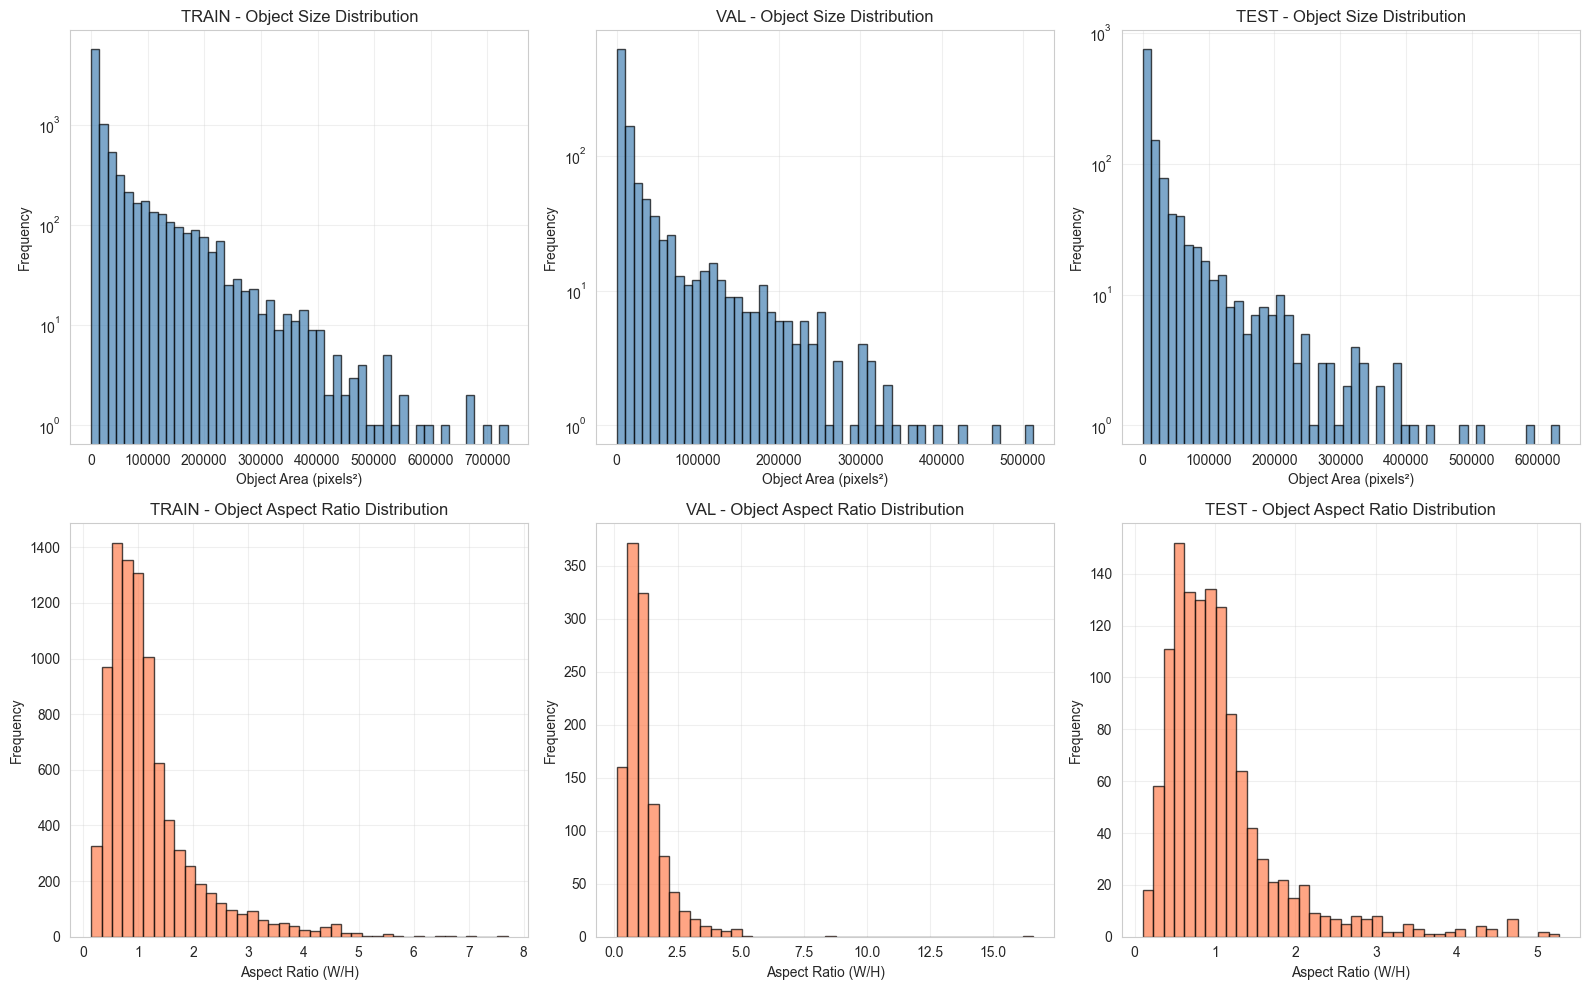

✓ Object metrics visualization saved


In [19]:
# Visualize object sizes and aspect ratios
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for split_idx, split in enumerate(splits):
    # Object sizes (areas) distribution
    areas_all = []
    for cid in object_metrics[split]:
        areas_all.extend(object_metrics[split][cid]['areas'])
    
    axes[0, split_idx].hist(areas_all, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    axes[0, split_idx].set_xlabel('Object Area (pixels²)')
    axes[0, split_idx].set_ylabel('Frequency')
    axes[0, split_idx].set_title(f'{split.upper()} - Object Size Distribution')
    axes[0, split_idx].set_yscale('log')
    axes[0, split_idx].grid(alpha=0.3)
    
    # Aspect ratio distribution
    aspects_all = []
    for cid in object_metrics[split]:
        aspects_all.extend(object_metrics[split][cid]['aspect_ratios'])
    
    axes[1, split_idx].hist(aspects_all, bins=40, color='coral', alpha=0.7, edgecolor='black')
    axes[1, split_idx].set_xlabel('Aspect Ratio (W/H)')
    axes[1, split_idx].set_ylabel('Frequency')
    axes[1, split_idx].set_title(f'{split.upper()} - Object Aspect Ratio Distribution')
    axes[1, split_idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/object_metrics_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Object metrics visualization saved')

## 4. Class Relationships & Co-occurrence Analysis

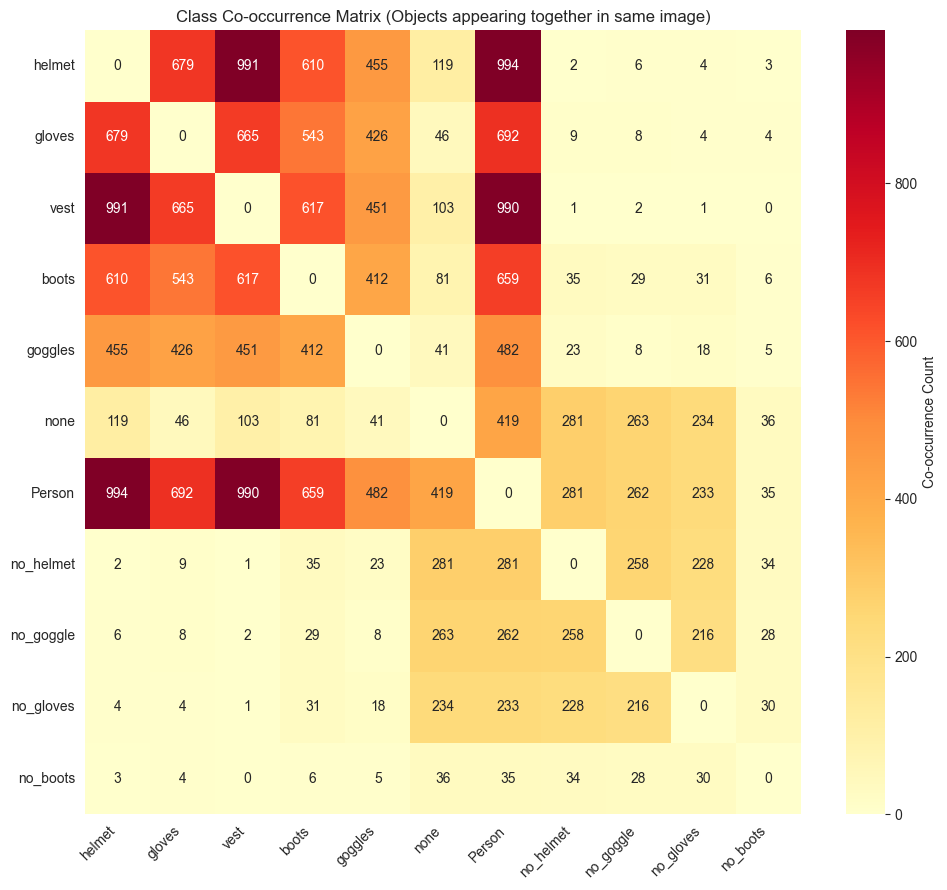

✓ Co-occurrence matrix visualization saved


In [20]:
# Build co-occurrence matrix - which classes appear together
cooccurrence = defaultdict(lambda: defaultdict(int))

for split in splits:
    for anns in [all_annotations[split]]:
        # Group annotations by image
        images_path = os.path.join(dataset_root, 'images', split)
        labels_path = os.path.join(dataset_root, 'labels', split)
        
        if os.path.exists(labels_path):
            for label_file in os.listdir(labels_path):
                label_path = os.path.join(labels_path, label_file)
                
                with open(label_path, 'r', encoding='utf-8') as f:
                    classes_in_image = set()
                    for line in f:
                        parts = line.strip().split()
                        if parts:
                            classes_in_image.add(int(parts[0]))
                    
                    # Create pairs
                    for c1 in classes_in_image:
                        for c2 in classes_in_image:
                            if c1 != c2:
                                cooccurrence[c1][c2] += 1

# Convert to matrix for heatmap
all_classes = set()
for c1 in cooccurrence:
    all_classes.add(c1)
    for c2 in cooccurrence[c1]:
        all_classes.add(c2)

all_classes = sorted(list(all_classes))
cooccurrence_matrix = np.zeros((len(all_classes), len(all_classes)))

for i, c1 in enumerate(all_classes):
    for j, c2 in enumerate(all_classes):
        cooccurrence_matrix[i, j] = cooccurrence[c1][c2]

# Visualize
fig, ax = plt.subplots(figsize=(10, 9))
labels = [class_names.get(c, f'ID_{c}') for c in all_classes]
sns.heatmap(cooccurrence_matrix, xticklabels=labels, yticklabels=labels, 
            cmap='YlOrRd', annot=True, fmt='.0f', cbar_kws={'label': 'Co-occurrence Count'}, ax=ax)
ax.set_title('Class Co-occurrence Matrix (Objects appearing together in same image)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/class_cooccurrence_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ Co-occurrence matrix visualization saved')

## 5. Spatial Distribution Analysis

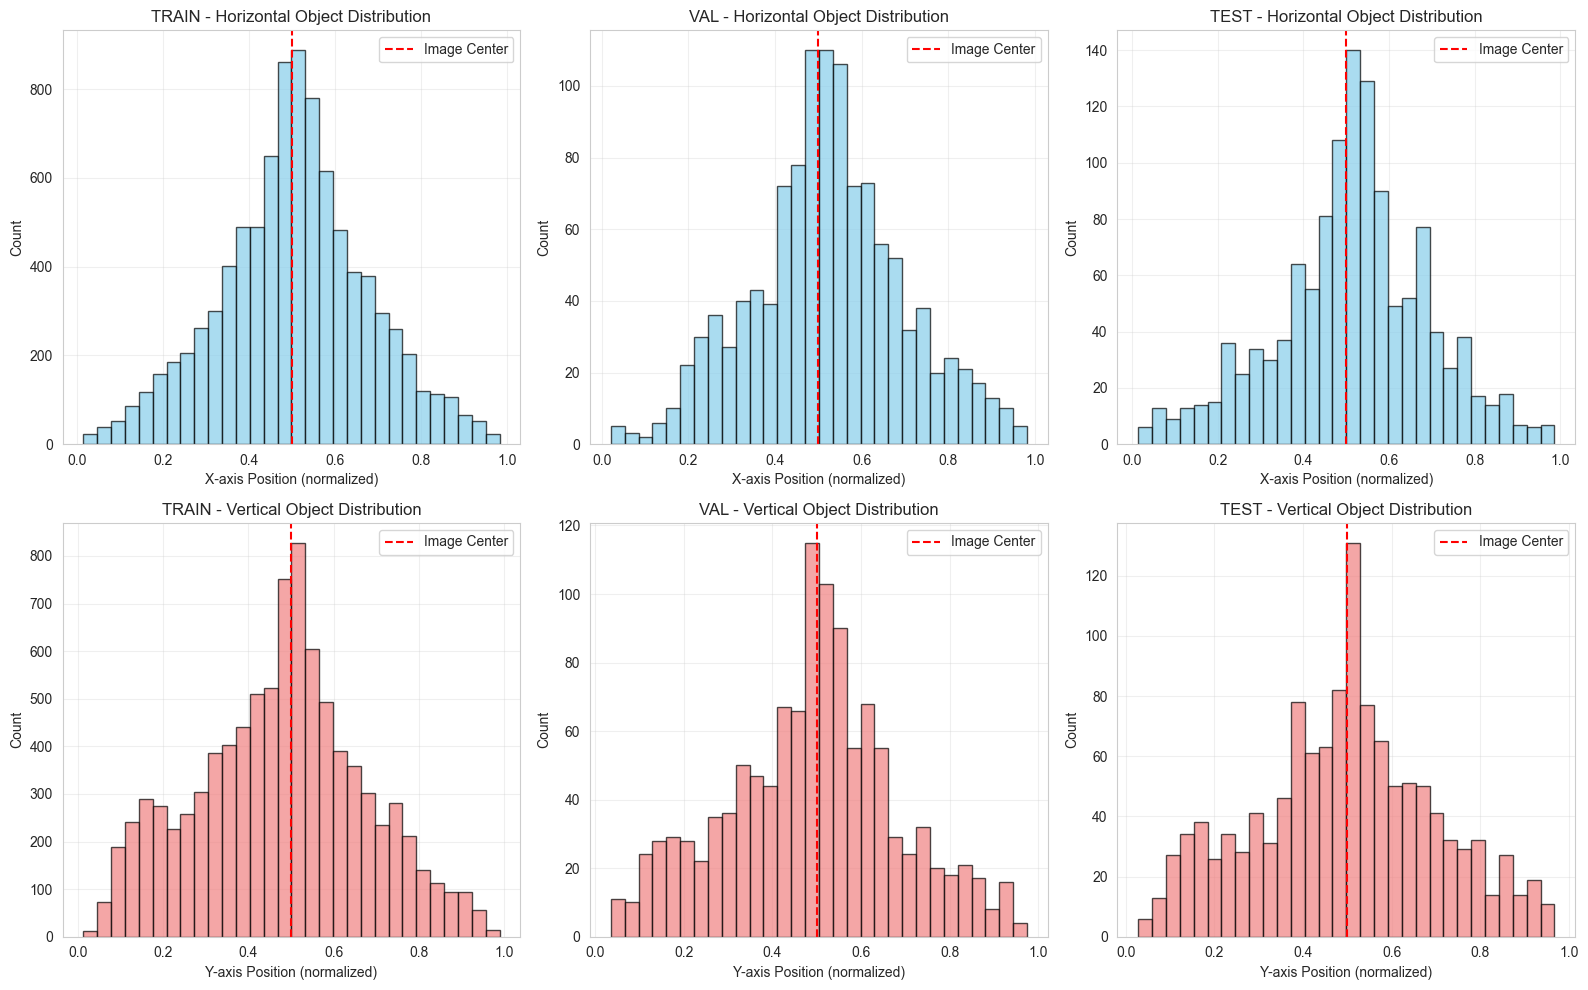

✓ Spatial distribution visualization saved


In [21]:
# Analyze where objects are positioned in images (center vs edges)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for split_idx, split in enumerate(splits):
    # X-axis center distribution
    x_centers = [ann['x_center'] for ann in all_annotations[split]]
    y_centers = [ann['y_center'] for ann in all_annotations[split]]
    
    axes[0, split_idx].hist(x_centers, bins=30, color='skyblue', alpha=0.7, edgecolor='black')
    axes[0, split_idx].axvline(x=0.5, color='red', linestyle='--', label='Image Center')
    axes[0, split_idx].set_xlabel('X-axis Position (normalized)')
    axes[0, split_idx].set_ylabel('Count')
    axes[0, split_idx].set_title(f'{split.upper()} - Horizontal Object Distribution')
    axes[0, split_idx].legend()
    axes[0, split_idx].grid(alpha=0.3)
    
    # Y-axis center distribution
    axes[1, split_idx].hist(y_centers, bins=30, color='lightcoral', alpha=0.7, edgecolor='black')
    axes[1, split_idx].axvline(x=0.5, color='red', linestyle='--', label='Image Center')
    axes[1, split_idx].set_xlabel('Y-axis Position (normalized)')
    axes[1, split_idx].set_ylabel('Count')
    axes[1, split_idx].set_title(f'{split.upper()} - Vertical Object Distribution')
    axes[1, split_idx].legend()
    axes[1, split_idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/spatial_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ Spatial distribution visualization saved')

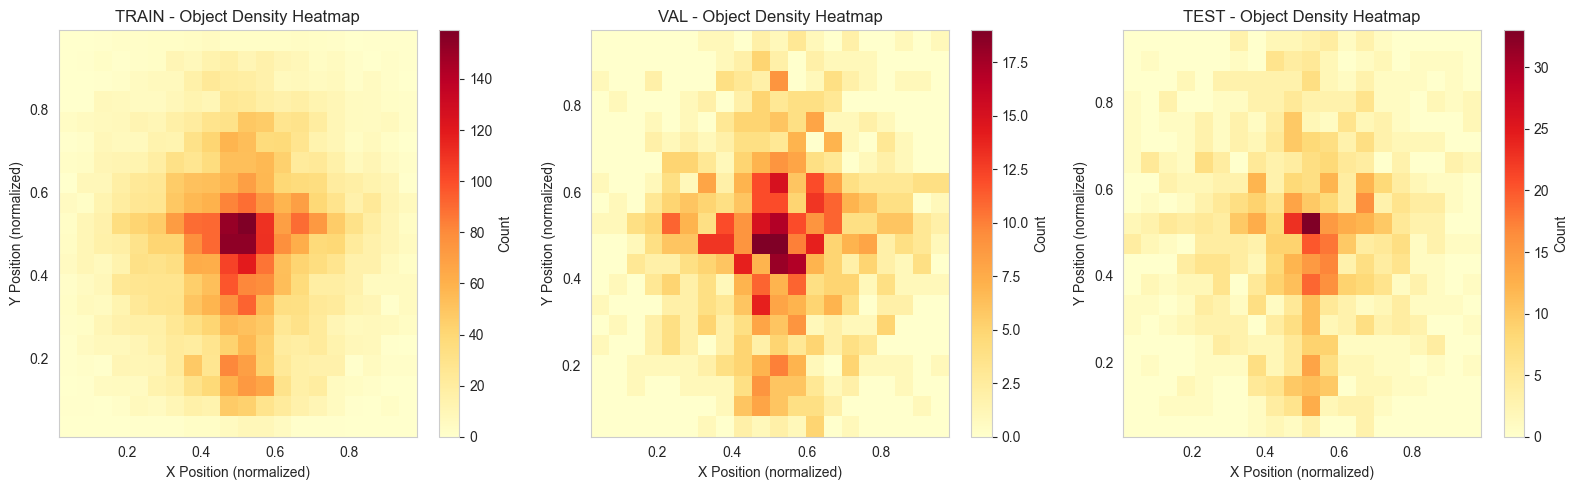

✓ Spatial density heatmap saved


In [22]:
# 2D density heatmap per split
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for split_idx, split in enumerate(splits):
    x_centers = np.array([ann['x_center'] for ann in all_annotations[split]])
    y_centers = np.array([ann['y_center'] for ann in all_annotations[split]])
    
    h = axes[split_idx].hist2d(x_centers, y_centers, bins=20, cmap='YlOrRd')
    axes[split_idx].set_xlabel('X Position (normalized)')
    axes[split_idx].set_ylabel('Y Position (normalized)')
    axes[split_idx].set_title(f'{split.upper()} - Object Density Heatmap')
    plt.colorbar(h[3], ax=axes[split_idx], label='Count')

plt.tight_layout()
plt.savefig('../data/spatial_density_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ Spatial density heatmap saved')

## 6. Data Quality Metrics & Outlier Detection

In [ ]:
# Detect data quality issues
quality_report = {}  # Changed from defaultdict(list) to regular dict

for split in splits:
    images_path = os.path.join(dataset_root, 'images', split)
    labels_path = os.path.join(dataset_root, 'labels', split)
    
    issues = {
        'total_images': 0,
        'unannotated': 0,
        'very_small_objects': 0,
        'very_large_objects': 0,
        'extreme_aspect_ratios': 0,
        'zero_size_boxes': 0,
        'missing_labels': 0,
        'total_objects': 0
    }
    
    if os.path.exists(images_path):
        for img_file in os.listdir(images_path):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                issues['total_images'] += 1
                
                img_path = os.path.join(images_path, img_file)
                label_file = img_file.rsplit('.', 1)[0] + '.txt'
                label_path = os.path.join(labels_path, label_file)
                
                if not os.path.exists(label_path):
                    issues['missing_labels'] += 1
                    issues['unannotated'] += 1
                    continue
                
                img = cv2.imread(img_path)
                if img is None:
                    continue
                
                h, w = img.shape[:2]
                img_area = h * w
                
                with open(label_path, 'r', encoding='utf-8') as f:
                    lines = f.readlines()
                    if len(lines) == 0:
                        issues['unannotated'] += 1
                    
                    for line in lines:
                        issues['total_objects'] += 1
                        parts = line.strip().split()
                        
                        if len(parts) >= 5:
                            width_n = float(parts[3])
                            height_n = float(parts[4])
                            
                            bbox_area = (width_n * w) * (height_n * h)
                            area_percent = (bbox_area / img_area) * 100
                            aspect = (width_n * w) / (height_n * h) if height_n > 0 else 0
                            
                            if width_n == 0 or height_n == 0:
                                issues['zero_size_boxes'] += 1
                            if area_percent < 0.01:
                                issues['very_small_objects'] += 1
                            if area_percent > 80:
                                issues['very_large_objects'] += 1
                            if aspect < 0.1 or aspect > 10:
                                issues['extreme_aspect_ratios'] += 1
    
    quality_report[split] = issues

# Display quality report
print('\nDATA QUALITY METRICS')
print('='*80)
for split in splits:
    issues = quality_report[split]
    print(f'\n{split.upper()}:')
    print(f'  Total Images: {issues["total_images"]}')
    print(f'  Unannotated Images: {issues["unannotated"]} ({100*issues["unannotated"]/max(issues["total_images"],1):.1f}%)')
    print(f'  Missing Labels: {issues["missing_labels"]}')
    print(f'  Total Objects Annotated: {issues["total_objects"]}')
    print(f'  Quality Issues:')
    print(f'    - Zero-size boxes: {issues["zero_size_boxes"]}')
    print(f'    - Very small objects (<0.01%): {issues["very_small_objects"]}')
    print(f'    - Very large objects (>80%): {issues["very_large_objects"]}')
    print(f'    - Extreme aspect ratios: {issues["extreme_aspect_ratios"]}')


DATA QUALITY METRICS

TRAIN:
  Total Images: 1132
  Unannotated Images: 0 (0.0%)
  Missing Labels: 0
  Total Objects Annotated: 9098
  Quality Issues:
    - Zero-size boxes: 0
    - Very small objects (<0.01%): 1
    - Very large objects (>80%): 12
    - Extreme aspect ratios: 0

VAL:
  Total Images: 143
  Unannotated Images: 0 (0.0%)
  Missing Labels: 0
  Total Objects Annotated: 1172
  Quality Issues:
    - Zero-size boxes: 0
    - Very small objects (<0.01%): 0
    - Very large objects (>80%): 2
    - Extreme aspect ratios: 2

TEST:
  Total Images: 141
  Unannotated Images: 0 (0.0%)
  Missing Labels: 0
  Total Objects Annotated: 1251
  Quality Issues:
    - Zero-size boxes: 0
    - Very small objects (<0.01%): 1
    - Very large objects (>80%): 2
    - Extreme aspect ratios: 0


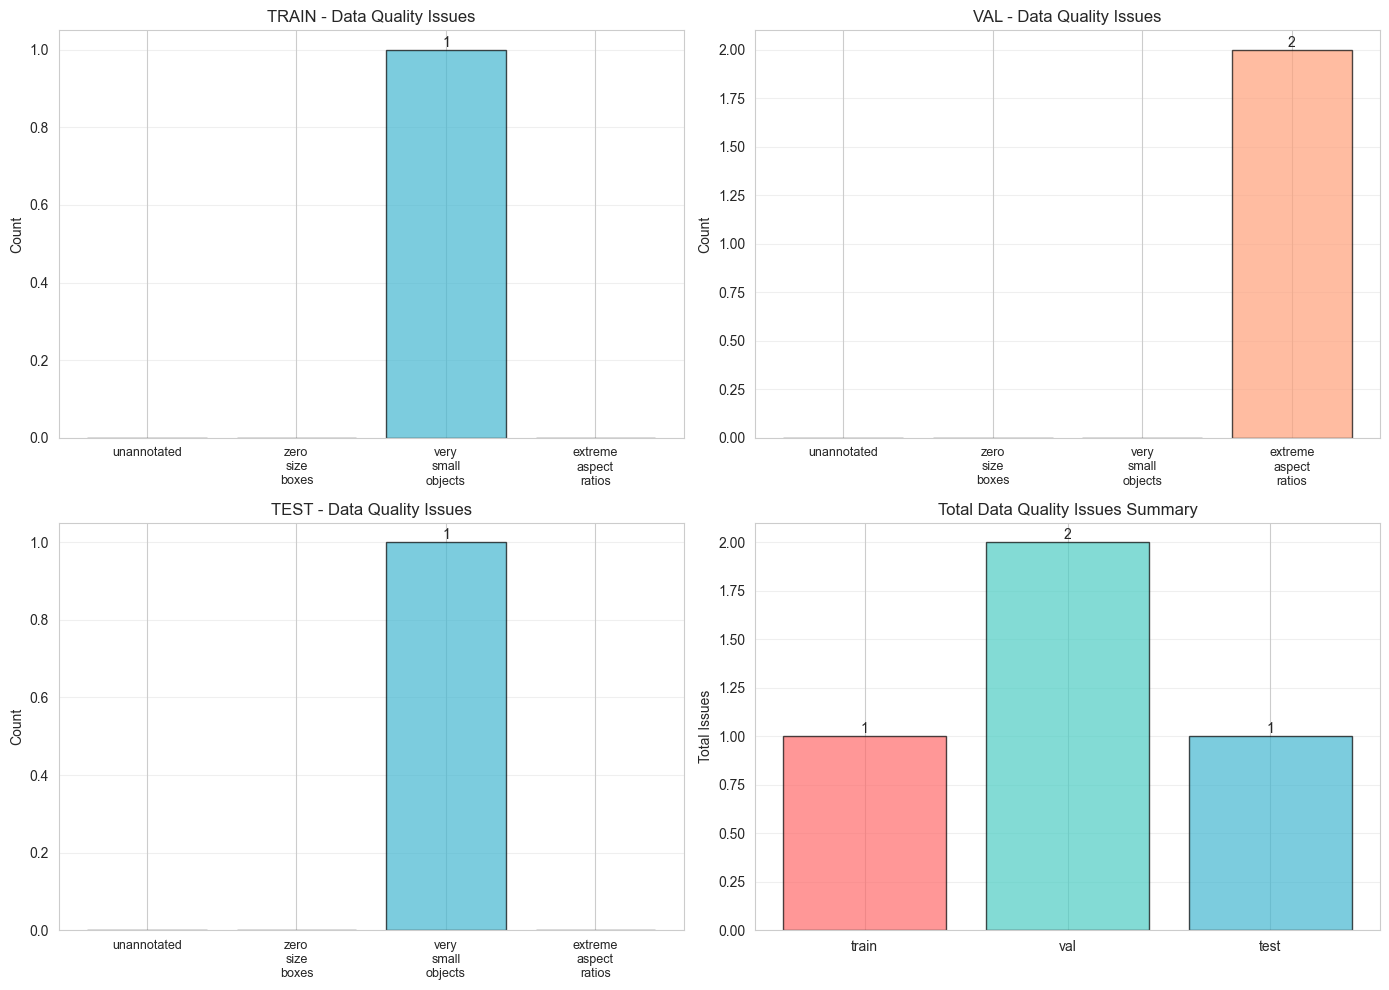

✓ Data quality metrics visualization saved


In [24]:
# Visualize quality metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Issue counts
issue_types = ['unannotated', 'zero_size_boxes', 'very_small_objects', 'extreme_aspect_ratios']
for idx, split in enumerate(splits):
    counts = [quality_report[split][issue] for issue in issue_types]
    colors_list = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
    
    if idx < 3:
        ax = axes[idx // 2, idx % 2]
    else:
        continue
    
    bars = ax.bar(range(len(issue_types)), counts, color=colors_list, alpha=0.7, edgecolor='black')
    ax.set_ylabel('Count')
    ax.set_title(f'{split.upper()} - Data Quality Issues')
    ax.set_xticks(range(len(issue_types)))
    ax.set_xticklabels([it.replace('_', '\n') for it in issue_types], fontsize=9)
    ax.grid(alpha=0.3, axis='y')
    
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}', ha='center', va='bottom')

# Summary statistics
ax = axes[1, 1]
summary_data = []
for split in splits:
    issues = quality_report[split]
    total_issues = (issues['unannotated'] + issues['zero_size_boxes'] + 
                   issues['very_small_objects'] + issues['extreme_aspect_ratios'])
    summary_data.append(total_issues)

ax.bar(splits, summary_data, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.7, edgecolor='black')
ax.set_ylabel('Total Issues')
ax.set_title('Total Data Quality Issues Summary')
ax.grid(alpha=0.3, axis='y')
for i, v in enumerate(summary_data):
    ax.text(i, v, str(int(v)), ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../data/data_quality_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Data quality metrics visualization saved')

## 7. Class Balance & Distribution Analysis

In [25]:
# Detailed class balance analysis
class_distribution = defaultdict(lambda: defaultdict(int))

for split in splits:
    labels_path = os.path.join(dataset_root, 'labels', split)
    if os.path.exists(labels_path):
        for label_file in os.listdir(labels_path):
            label_path = os.path.join(labels_path, label_file)
            with open(label_path, 'r', encoding='utf-8') as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        class_id = int(parts[0])
                        class_distribution[split][class_id] += 1

# Analyze balance
print('\nCLASS BALANCE ANALYSIS')
print('='*80)
for split in splits:
    print(f'\n{split.upper()}:')
    total = sum(class_distribution[split].values())
    
    sorted_classes = sorted(class_distribution[split].items(), key=lambda x: x[1], reverse=True)
    min_count = min([c[1] for c in sorted_classes])
    max_count = max([c[1] for c in sorted_classes])
    
    print(f'  Total objects: {total}')
    print(f'  Min-Max ratio: {max_count/min_count:.1f}x (Max: {max_count}, Min: {min_count})')
    print(f'\n  Per-class breakdown:')
    
    for class_id, count in sorted_classes:
        percent = (count / total) * 100
        bar_len = int(percent / 2)
        bar = '■' * bar_len
        print(f'    {class_names.get(class_id, f"ID_{class_id}"):15s}: {count:5d} ({percent:5.1f}%) {bar}')


CLASS BALANCE ANALYSIS

TRAIN:
  Total objects: 9191
  Min-Max ratio: 20.3x (Max: 1790, Min: 88)

  Per-class breakdown:
    Person         :  1790 ( 19.5%) ■■■■■■■■■
    helmet         :  1357 ( 14.8%) ■■■■■■■
    vest           :  1283 ( 14.0%) ■■■■■■
    boots          :  1251 ( 13.6%) ■■■■■■
    gloves         :  1162 ( 12.6%) ■■■■■■
    none           :   654 (  7.1%) ■■■
    no_gloves      :   442 (  4.8%) ■■
    goggles        :   427 (  4.6%) ■■
    no_helmet      :   400 (  4.4%) ■■
    no_goggle      :   337 (  3.7%) ■
    no_boots       :    88 (  1.0%) 

VAL:
  Total objects: 1172
  Min-Max ratio: 59.8x (Max: 239, Min: 4)

  Per-class breakdown:
    Person         :   239 ( 20.4%) ■■■■■■■■■■
    helmet         :   201 ( 17.2%) ■■■■■■■■
    vest           :   171 ( 14.6%) ■■■■■■■
    boots          :   151 ( 12.9%) ■■■■■■
    gloves         :   136 ( 11.6%) ■■■■■
    none           :    81 (  6.9%) ■■■
    no_gloves      :    56 (  4.8%) ■■
    goggles        :    47 (  4.0

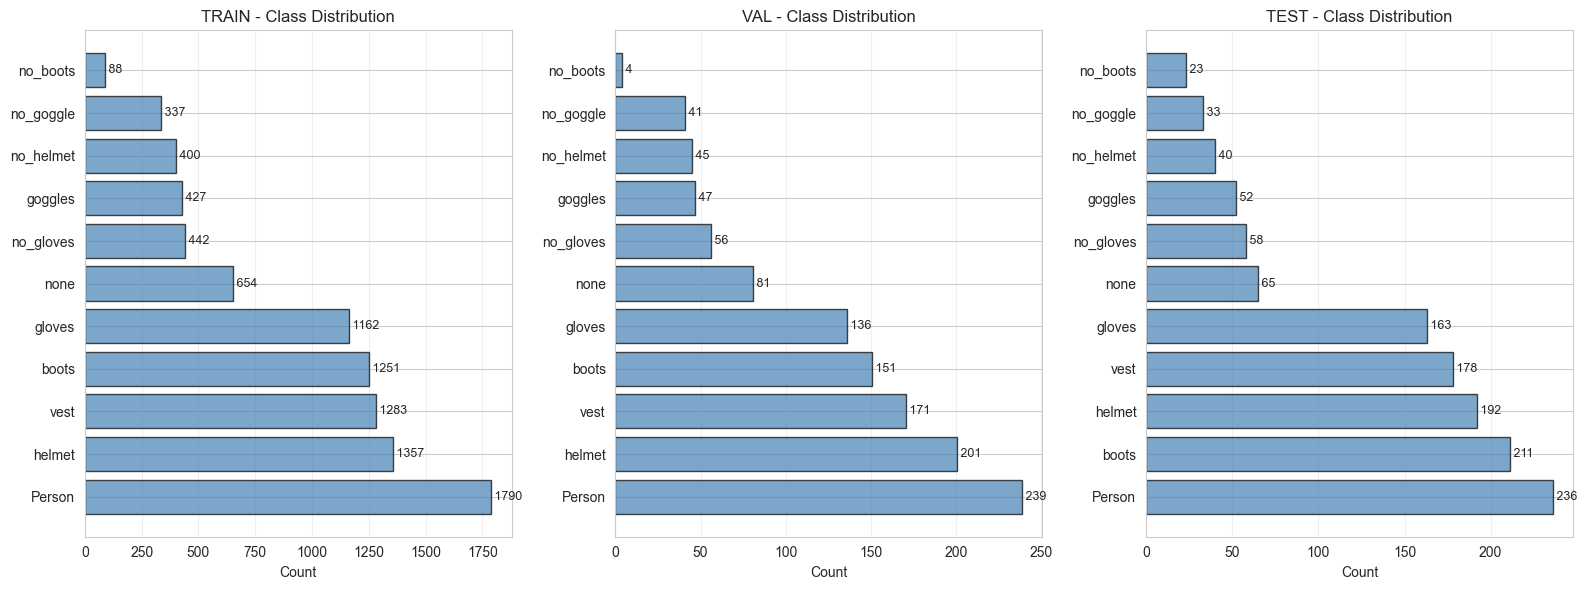

✓ Class balance visualization saved


In [26]:
# Visualize class imbalance
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for split_idx, split in enumerate(splits):
    data = class_distribution[split]
    sorted_classes = sorted(data.items(), key=lambda x: x[1], reverse=True)
    
    class_ids = [c[0] for c in sorted_classes]
    counts = [c[1] for c in sorted_classes]
    labels = [class_names.get(cid, f'ID_{cid}') for cid in class_ids]
    
    axes[split_idx].barh(labels, counts, color='steelblue', alpha=0.7, edgecolor='black')
    axes[split_idx].set_xlabel('Count')
    axes[split_idx].set_title(f'{split.upper()} - Class Distribution')
    axes[split_idx].grid(alpha=0.3, axis='x')
    
    for i, count in enumerate(counts):
        axes[split_idx].text(count, i, f' {count}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/class_balance_detailed.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Class balance visualization saved')

## 8. Training Dataset Readiness Assessment

In [29]:
# Re-initialize all required variables for Section 8
# This ensures Section 8 can run independently

# 1. Count images per split
image_stats = {}
for split in splits:
    images_path = os.path.join(dataset_root, 'images', split)
    if os.path.exists(images_path):
        image_files = [f for f in os.listdir(images_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        image_stats[split] = len(image_files)
    else:
        image_stats[split] = 0

# 2. Collect image properties if not already done
if 'image_properties' not in dir() or not image_properties.get('train'):
    image_properties = defaultdict(lambda: {
        'widths': [], 'heights': [], 'aspect_ratios': []
    })
    for split in splits:
        images_path = os.path.join(dataset_root, 'images', split)
        if os.path.exists(images_path):
            for img_file in os.listdir(images_path):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    img_path = os.path.join(images_path, img_file)
                    img = cv2.imread(img_path)
                    if img is not None:
                        h, w = img.shape[:2]
                        image_properties[split]['widths'].append(w)
                        image_properties[split]['heights'].append(h)
                        image_properties[split]['aspect_ratios'].append(w / h if h > 0 else 0)

# 3. Collect class distribution if not already done
if 'class_distribution' not in dir() or not class_distribution.get('train'):
    class_distribution = defaultdict(lambda: defaultdict(int))
    for split in splits:
        labels_path = os.path.join(dataset_root, 'labels', split)
        if os.path.exists(labels_path):
            for label_file in os.listdir(labels_path):
                label_path = os.path.join(labels_path, label_file)
                with open(label_path, 'r', encoding='utf-8') as f:
                    for line in f:
                        parts = line.strip().split()
                        if parts:
                            class_id = int(parts[0])
                            class_distribution[split][class_id] += 1

# 4. Collect quality metrics if not already done
if 'quality_report' not in dir() or not quality_report.get('train'):
    quality_report = defaultdict(dict)
    for split in splits:
        images_path = os.path.join(dataset_root, 'images', split)
        labels_path = os.path.join(dataset_root, 'labels', split)
        
        issues = {
            'total_images': 0,
            'unannotated': 0,
            'very_small_objects': 0,
            'very_large_objects': 0,
            'extreme_aspect_ratios': 0,
            'zero_size_boxes': 0,
            'missing_labels': 0,
            'total_objects': 0
        }
        
        if os.path.exists(images_path):
            for img_file in os.listdir(images_path):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    issues['total_images'] += 1
                    
                    img_path = os.path.join(images_path, img_file)
                    label_file = img_file.rsplit('.', 1)[0] + '.txt'
                    label_path = os.path.join(labels_path, label_file)
                    
                    if not os.path.exists(label_path):
                        issues['missing_labels'] += 1
                        issues['unannotated'] += 1
                        continue
                    
                    img = cv2.imread(img_path)
                    if img is None:
                        continue
                    
                    h, w = img.shape[:2]
                    img_area = h * w
                    
                    with open(label_path, 'r', encoding='utf-8') as f:
                        lines = f.readlines()
                        if len(lines) == 0:
                            issues['unannotated'] += 1
                        
                        for line in lines:
                            issues['total_objects'] += 1
                            parts = line.strip().split()
                            
                            if len(parts) >= 5:
                                width_n = float(parts[3])
                                height_n = float(parts[4])
                                
                                bbox_area = (width_n * w) * (height_n * h)
                                area_percent = (bbox_area / img_area) * 100 if img_area > 0 else 0
                                aspect = (width_n * w) / (height_n * h) if height_n > 0 else 0
                                
                                if width_n == 0 or height_n == 0:
                                    issues['zero_size_boxes'] += 1
                                if area_percent < 0.01:
                                    issues['very_small_objects'] += 1
                                if area_percent > 80:
                                    issues['very_large_objects'] += 1
                                if aspect < 0.1 or aspect > 10:
                                    issues['extreme_aspect_ratios'] += 1
        
        quality_report[split] = issues

print('✓ All variables re-initialized successfully')

✓ All variables re-initialized successfully


In [30]:
# Comprehensive readiness assessment
print('\nTRAINING DATASET READINESS ASSESSMENT')
print('='*80)

assessment = {
    'Dataset Size': '✓ GOOD' if sum(image_stats.values()) > 1000 else '✗ NEEDS IMPROVEMENT',
    'Train/Val/Test Split': '✓ GOOD' if all(image_stats[s] > 100 for s in splits) else '✗ IMBALANCED',
    'Image Consistency': '✓ GOOD' if np.std(image_properties['train']['widths']) < 200 else '✗ HIGH VARIATION',
    'Class Coverage': '✓ GOOD' if all(len(class_distribution[s]) >= 6 for s in splits) else '✗ MISSING CLASSES',
    'Data Quality': '✓ GOOD' if all(quality_report[s]['unannotated'] == 0 for s in splits) else '✗ UNANNOTATED IMAGES',
    'Class Balance': '✓ GOOD' if max(max(class_distribution[s].values())/min(class_distribution[s].values()) for s in splits) < 5 else '✗ IMBALANCED',
}

for metric, status in assessment.items():
    print(f'{metric:25s}: {status}')

print('\n' + '='*80)
print('RECOMMENDATIONS FOR MODEL TRAINING')
print('='*80)

recommendations = []
if sum(image_stats.values()) < 500:
    recommendations.append('• Dataset is small. Consider data augmentation during training.')
if sum(image_stats.values()) > 5000:
    recommendations.append('• Large dataset. May require longer training time and optimized hardware.')

if any(quality_report[s]['very_small_objects'] > 100 for s in splits):
    recommendations.append('• Many very small objects detected. Consider preprocessing or multi-scale detection.')

if any(quality_report[s]['extreme_aspect_ratios'] > 100 for s in splits):
    recommendations.append('• Objects with extreme aspect ratios found. May require special augmentation strategies.')

for split in splits:
    total = sum(class_distribution[split].values())
    if total > 0:
        counts = list(class_distribution[split].values())
        if max(counts) / min(counts) > 10:
            recommendations.append(f'• {split.upper()}: Severe class imbalance detected. Use weighted loss or resampling.')

if len(recommendations) == 0:
    recommendations.append('✓ Dataset appears ready for training with standard YOLOv8 configuration.')

for rec in recommendations:
    print(rec)

print('\n' + '='*80)
print('SUGGESTED TRAINING PARAMETERS')
print('='*80)
print(f'Image Size: 640x640 (based on aspect ratio analysis)')
print(f'Batch Size: 16 (adjust based on GPU memory)')
print(f'Epochs: 100')
print(f'Augmentation: Enable (flip, mosaic, HSV)')
print(f'Optimizer: SGD')
print(f'Learning Rate: Start with 0.01, use cosine scheduler')


TRAINING DATASET READINESS ASSESSMENT
Dataset Size             : ✓ GOOD
Train/Val/Test Split     : ✓ GOOD
Image Consistency        : ✓ GOOD
Class Coverage           : ✓ GOOD
Data Quality             : ✓ GOOD
Class Balance            : ✗ IMBALANCED

RECOMMENDATIONS FOR MODEL TRAINING
• TRAIN: Severe class imbalance detected. Use weighted loss or resampling.
• VAL: Severe class imbalance detected. Use weighted loss or resampling.
• TEST: Severe class imbalance detected. Use weighted loss or resampling.

SUGGESTED TRAINING PARAMETERS
Image Size: 640x640 (based on aspect ratio analysis)
Batch Size: 16 (adjust based on GPU memory)
Epochs: 100
Augmentation: Enable (flip, mosaic, HSV)
Optimizer: SGD
Learning Rate: Start with 0.01, use cosine scheduler


In [31]:
# SAFETY CHECK: Ensure all required variables are defined before assessment
try:
    assert 'image_stats' in dir() and image_stats
    assert 'image_properties' in dir() and image_properties
    assert 'class_distribution' in dir() and class_distribution
    assert 'quality_report' in dir() and quality_report
    print('✓ All required variables are defined')
except (AssertionError, NameError):
    print('⚠️  RUNNING SETUP - Missing variables detected...\n')
    
    # 1. Count images per split
    image_stats = {}
    for split in splits:
        images_path = os.path.join(dataset_root, 'images', split)
        if os.path.exists(images_path):
            image_files = [f for f in os.listdir(images_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            image_stats[split] = len(image_files)
        else:
            image_stats[split] = 0
    print(f'  ✓ Loaded image_stats: {image_stats}')
    
    # 2. Collect image properties
    image_properties = defaultdict(lambda: {
        'widths': [], 'heights': [], 'aspect_ratios': []
    })
    for split in splits:
        images_path = os.path.join(dataset_root, 'images', split)
        if os.path.exists(images_path):
            for img_file in os.listdir(images_path):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    img_path = os.path.join(images_path, img_file)
                    img = cv2.imread(img_path)
                    if img is not None:
                        h, w = img.shape[:2]
                        image_properties[split]['widths'].append(w)
                        image_properties[split]['heights'].append(h)
                        image_properties[split]['aspect_ratios'].append(w / h if h > 0 else 0)
    print(f'  ✓ Loaded image_properties for {len(image_properties)} splits')
    
    # 3. Collect class distribution
    class_distribution = defaultdict(lambda: defaultdict(int))
    for split in splits:
        labels_path = os.path.join(dataset_root, 'labels', split)
        if os.path.exists(labels_path):
            for label_file in os.listdir(labels_path):
                label_path = os.path.join(labels_path, label_file)
                with open(label_path, 'r', encoding='utf-8') as f:
                    for line in f:
                        parts = line.strip().split()
                        if parts:
                            class_id = int(parts[0])
                            class_distribution[split][class_id] += 1
    print(f'  ✓ Loaded class_distribution for {len(class_distribution)} splits')
    
    # 4. Collect quality metrics
    quality_report = {}
    for split in splits:
        images_path = os.path.join(dataset_root, 'images', split)
        labels_path = os.path.join(dataset_root, 'labels', split)
        
        issues = {
            'total_images': 0, 'unannotated': 0, 'very_small_objects': 0,
            'very_large_objects': 0, 'extreme_aspect_ratios': 0,
            'zero_size_boxes': 0, 'missing_labels': 0, 'total_objects': 0
        }
        
        if os.path.exists(images_path):
            for img_file in os.listdir(images_path):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    issues['total_images'] += 1
                    img_path = os.path.join(images_path, img_file)
                    label_file = img_file.rsplit('.', 1)[0] + '.txt'
                    label_path = os.path.join(labels_path, label_file)
                    
                    if not os.path.exists(label_path):
                        issues['missing_labels'] += 1
                        issues['unannotated'] += 1
                        continue
                    
                    img = cv2.imread(img_path)
                    if img is None:
                        continue
                    
                    h, w = img.shape[:2]
                    img_area = h * w
                    
                    with open(label_path, 'r', encoding='utf-8') as f:
                        lines = f.readlines()
                        if len(lines) == 0:
                            issues['unannotated'] += 1
                        
                        for line in lines:
                            issues['total_objects'] += 1
                            parts = line.strip().split()
                            if len(parts) >= 5:
                                width_n, height_n = float(parts[3]), float(parts[4])
                                bbox_area = (width_n * w) * (height_n * h)
                                area_percent = (bbox_area / img_area) * 100 if img_area > 0 else 0
                                aspect = (width_n * w) / (height_n * h) if height_n > 0 else 0
                                
                                if width_n == 0 or height_n == 0:
                                    issues['zero_size_boxes'] += 1
                                if area_percent < 0.01:
                                    issues['very_small_objects'] += 1
                                if area_percent > 80:
                                    issues['very_large_objects'] += 1
                                if aspect < 0.1 or aspect > 10:
                                    issues['extreme_aspect_ratios'] += 1
        
        quality_report[split] = issues
    print(f'  ✓ Loaded quality_report for {len(quality_report)} splits')
    print('\n✓ All variables initialized successfully!')

✓ All required variables are defined


## 9. Comprehensive Summary Dashboard

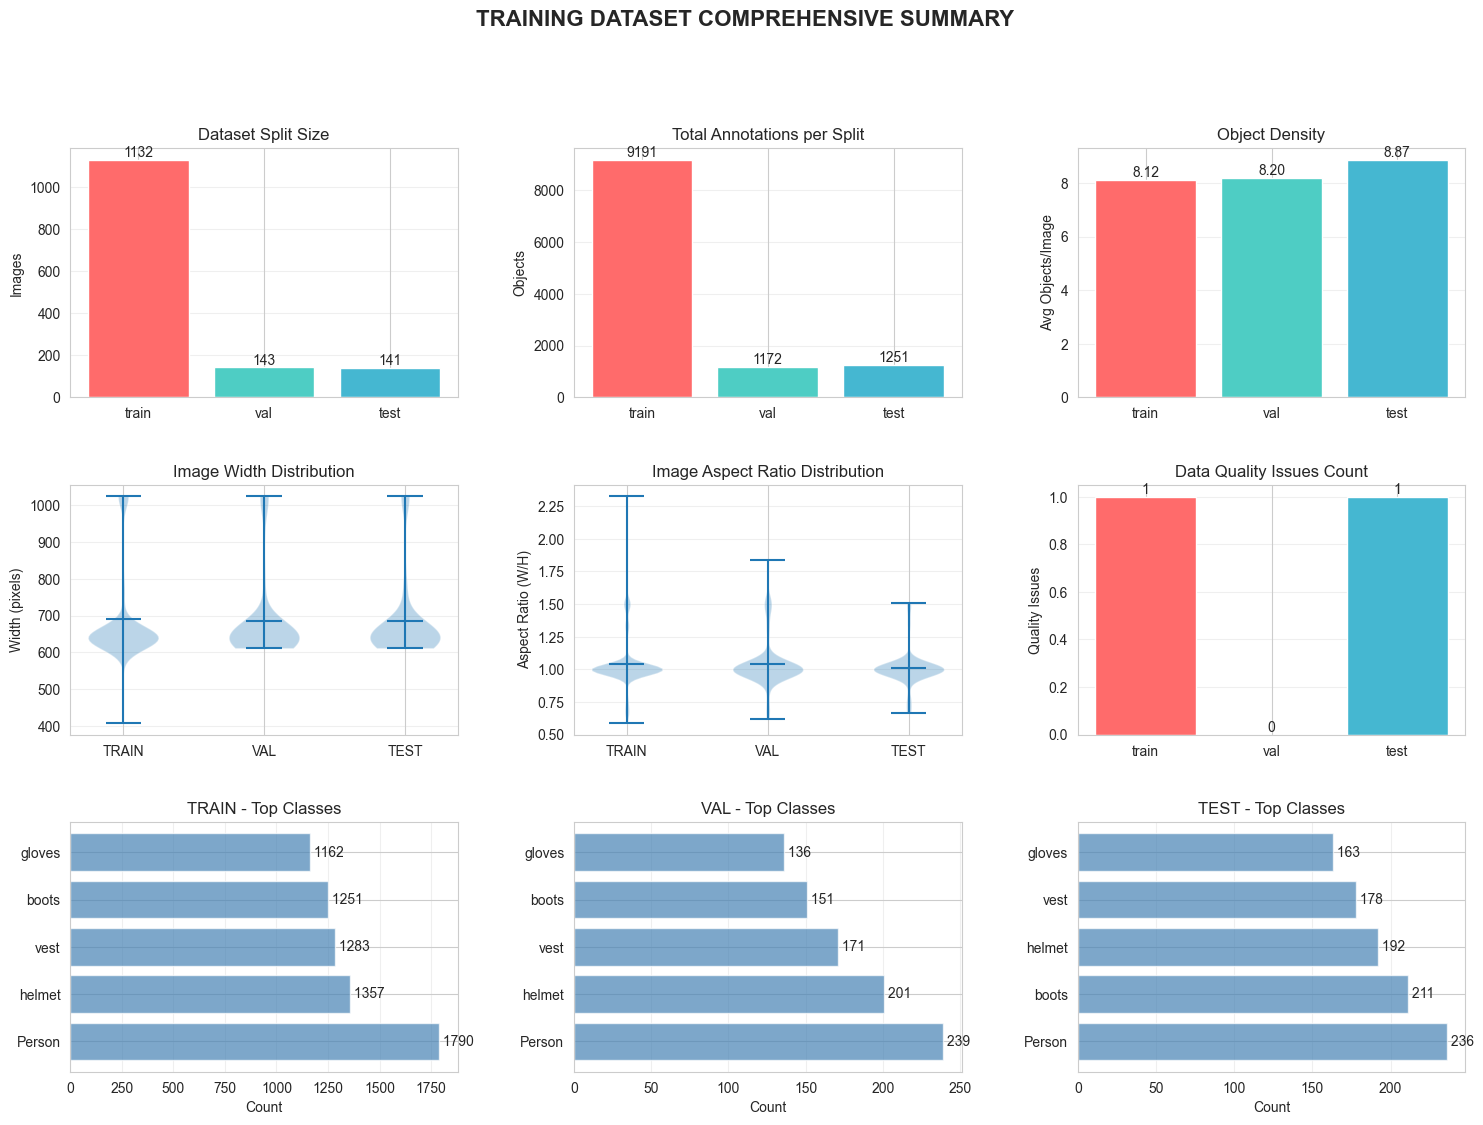

✓ Comprehensive summary dashboard saved


In [32]:
# Create comprehensive summary visualization
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# 1. Dataset overview
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(splits, [image_stats[s] for s in splits], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax1.set_ylabel('Images')
ax1.set_title('Dataset Split Size')
ax1.grid(alpha=0.3, axis='y')
for i, split in enumerate(splits):
    ax1.text(i, image_stats[split], str(image_stats[split]), ha='center', va='bottom')

# 2. Total objects per split
ax2 = fig.add_subplot(gs[0, 1])
total_objs = [sum(class_distribution[s].values()) for s in splits]
ax2.bar(splits, total_objs, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax2.set_ylabel('Objects')
ax2.set_title('Total Annotations per Split')
ax2.grid(alpha=0.3, axis='y')
for i, total in enumerate(total_objs):
    ax2.text(i, total, str(total), ha='center', va='bottom')

# 3. Avg objects per image
ax3 = fig.add_subplot(gs[0, 2])
avg_objs = [total_objs[i] / max(image_stats[splits[i]], 1) for i in range(len(splits))]
ax3.bar(splits, avg_objs, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax3.set_ylabel('Avg Objects/Image')
ax3.set_title('Object Density')
ax3.grid(alpha=0.3, axis='y')
for i, avg in enumerate(avg_objs):
    ax3.text(i, avg, f'{avg:.2f}', ha='center', va='bottom')

# 4. Image dimension violin plot
ax4 = fig.add_subplot(gs[1, 0])
width_data = [image_properties[s]['widths'] for s in splits]
ax4.violinplot(width_data, positions=range(len(splits)), showmeans=True)
ax4.set_ylabel('Width (pixels)')
ax4.set_xticks(range(len(splits)))
ax4.set_xticklabels([s.upper() for s in splits])
ax4.set_title('Image Width Distribution')
ax4.grid(alpha=0.3, axis='y')

# 5. Aspect ratio violin plot
ax5 = fig.add_subplot(gs[1, 1])
aspect_data = [image_properties[s]['aspect_ratios'] for s in splits]
ax5.violinplot(aspect_data, positions=range(len(splits)), showmeans=True)
ax5.set_ylabel('Aspect Ratio (W/H)')
ax5.set_xticks(range(len(splits)))
ax5.set_xticklabels([s.upper() for s in splits])
ax5.set_title('Image Aspect Ratio Distribution')
ax5.grid(alpha=0.3, axis='y')

# 6. Data quality issues
ax6 = fig.add_subplot(gs[1, 2])
issue_counts = [sum([quality_report[s][issue] for issue in ['unannotated', 'zero_size_boxes', 'very_small_objects']]) 
                for s in splits]
ax6.bar(splits, issue_counts, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax6.set_ylabel('Quality Issues')
ax6.set_title('Data Quality Issues Count')
ax6.grid(alpha=0.3, axis='y')
for i, count in enumerate(issue_counts):
    ax6.text(i, count, str(count), ha='center', va='bottom')

# 7-9. Top classes per split
for split_idx, split in enumerate(splits):
    ax = fig.add_subplot(gs[2, split_idx])
    sorted_classes = sorted(class_distribution[split].items(), key=lambda x: x[1], reverse=True)[:5]
    class_ids = [c[0] for c in sorted_classes]
    counts = [c[1] for c in sorted_classes]
    labels = [class_names.get(cid, f'ID_{cid}') for cid in class_ids]
    
    ax.barh(labels, counts, color='steelblue', alpha=0.7)
    ax.set_xlabel('Count')
    ax.set_title(f'{split.upper()} - Top Classes')
    ax.grid(alpha=0.3, axis='x')
    for i, count in enumerate(counts):
        ax.text(count, i, f' {count}', va='center')

plt.suptitle('TRAINING DATASET COMPREHENSIVE SUMMARY', fontsize=16, fontweight='bold', y=0.995)
plt.savefig('../data/comprehensive_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Comprehensive summary dashboard saved')